# Scientific Validity of PPI++ for Binary Mean Estimation

This notebook provides empirical evidence that GLIDE's **Prediction-Powered Inference (PPI++)** implementation is statistically valid.

**Setup:** We estimate the mean of a binary outcome (e.g., the pass rate of an LLM-as-a-judge evaluation). We have:
- A small set of **true labels** (`y_true`) — expensive but unbiased
- A large set of **proxy labels** (`y_proxy`) — cheap but potentially biased

PPI++ combines both to produce confidence intervals that are:
1. **Valid** — they cover the true mean at the specified rate (e.g. 90% confidence)
2. **Shorter** — as compared to those obtained with true labels only, especially when the proxy is strongly correlated with the truth

We test these two claims empirically across a range of proxy/true correlation levels.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm as sp_norm

from glide.core.dataset import Dataset
from glide.core.simulated import generate_dataset_binary
from glide.estimators import ClassicalMeanEstimator, PPIMeanEstimator

## Experiment Parameters

We fix all parameters up front so every section of this notebook uses a consistent setup.

> **Note on correlation bounds:** Depending on the values of TRUE_MEAN and PROXY_MEAN, extreme correlation values (close to 0 or 1) may not be possible. Correlation sweeps are kept within these limit.

In [12]:
CONFIDENCE_LEVEL = 0.9   # fixed throughout — 90% CI
N_TRUE = 500
N_PROXY = 1000
TRUE_MEAN = 0.55
PROXY_MEAN = 0.5
N_SEEDS = 500

METHODS = ['True only', 'Proxy only', 'PPI++']

# Correlation sweeps used across sections 3–5
correlations   = np.arange(0.1, 0.95, 0.1)   # full sweep (9 values)
correlations_3 = [0.15, 0.50, 0.85]           # three representative values for CL sweep
corr_labels    = ["Low", "Medium", "High"]

## 1. Data Generation

We use `generate_dataset_binary` to simulate a realistic evaluation scenario.
It generates correlated binary labels `(y_true, y_proxy)` for `N_TRUE` items, plus `N_PROXY` items with only `y_proxy` available.

The `correlation` parameter controls the Pearson correlation between true and proxy labels on the labeled subset.

In [13]:
# Single example dataset for illustration
example_dataset = generate_dataset_binary(
    n=N_TRUE,
    N=N_PROXY,
    true_mean=TRUE_MEAN,
    proxy_mean=PROXY_MEAN,
    correlation=0.8,
    random_seed=42,
)

data_array = example_dataset.to_numpy(fields=["y_true", "y_proxy"])

## 2. Estimation Methods

We compare three estimators:

| Method | Data used | Notes |
|--------|-----------|-------|
| **True only** | `y_true` | Classical CLT CI — the gold standard for validity |
| **Proxy only** | `y_proxy` | Biased — cheap but wrong |
| **PPI++** | `y_true` + `y_proxy` (corrected) | Our method — valid and efficient |

The classical baselines are computed with `ClassicalMeanEstimator`:
- **True only** — pass `y_field="y_true"` to use only the labeled ground-truth annotations.
- **Proxy only** — pass `y_field="y_proxy"` to use all proxy predictions (labeled + unlabeled).

Both calls are symmetric with `PPIMeanEstimator.estimate()` and return a `ClassicalMeanInferenceResult`.

The function below computes means and confidence intervals using three methods :
- true labels only
- proxy labels only
- true labels and proxy labels combined using PPI++

In [14]:
def generate_estimates(dataset, confidence_level=CONFIDENCE_LEVEL):
    """Return mean, std, and CI for all three methods."""
    # --- PPI++ ---
    ppi_result = PPIMeanEstimator().estimate(
        dataset,
        y_true_field="y_true",
        y_proxy_field="y_proxy",
        confidence_level=confidence_level,
    )

    # --- Classical baselines ---
    true_only_result = ClassicalMeanEstimator().estimate(
        dataset, y_field="y_true", confidence_level=confidence_level
    )
    proxy_only_result = ClassicalMeanEstimator().estimate(
        dataset, y_field="y_proxy", confidence_level=confidence_level
    )

    return {
        'True only': {
            "mean": true_only_result.mean,
            "std":  true_only_result.std,
            "CI":   (true_only_result.confidence_interval.lower_bound,
                     true_only_result.confidence_interval.upper_bound),
        },
        'Proxy only': {
            "mean": proxy_only_result.mean,
            "std":  proxy_only_result.std,
            "CI":   (proxy_only_result.confidence_interval.lower_bound,
                     proxy_only_result.confidence_interval.upper_bound),
        },
        'PPI++': {
            "mean": ppi_result.mean,
            "std":  ppi_result.std,
            "CI":   (ppi_result.confidence_interval.lower_bound,
                     ppi_result.confidence_interval.upper_bound),
            "ess":  ppi_result.effective_sample_size,
        },
    }

In [15]:
def simulate_all(correlation, n_seeds=N_SEEDS):
    """Single Monte Carlo loop: cache per-seed mean, std, and ESS for each method.

    Returns
    -------
    stats : dict
        stats[method]['means'], stats[method]['stds'] — float arrays of length n_seeds
        stats['PPI++']['ess']                         — float array of length n_seeds
    """
    means = {m: np.zeros(n_seeds) for m in METHODS}
    stds  = {m: np.zeros(n_seeds) for m in METHODS}
    ess   = np.zeros(n_seeds)

    for seed in range(n_seeds):
        ds = generate_dataset_binary(
            n=N_TRUE, N=N_PROXY,
            true_mean=TRUE_MEAN, proxy_mean=PROXY_MEAN,
            correlation=correlation, random_seed=seed,
        )
        est = generate_estimates(ds)
        for m in METHODS:
            means[m][seed] = est[m]['mean']
            stds[m][seed]  = est[m]['std']
        ess[seed] = est['PPI++']['ess']

    stats = {m: {'means': means[m], 'stds': stds[m]} for m in METHODS}
    stats['PPI++']['ess'] = ess
    return stats


def compute_hits(stats, confidence_level):
    """Return per-seed hit indicators {method: float array} at the given confidence level."""
    z = sp_norm.ppf((1 + confidence_level) / 2)
    hits = {}
    for m in METHODS:
        lo = stats[m]['means'] - z * stats[m]['stds']
        hi = stats[m]['means'] + z * stats[m]['stds']
        hits[m] = ((lo <= TRUE_MEAN) & (TRUE_MEAN <= hi)).astype(float)
    return hits


def coverage_with_errbar(hit_array, confidence_level=CONFIDENCE_LEVEL):
    """Estimate empirical coverage + CI via ClassicalMeanEstimator on per-seed hit indicators."""
    ds = Dataset([{"hit": h} for h in hit_array])
    r = ClassicalMeanEstimator().estimate(ds, y_field="hit", confidence_level=confidence_level)
    return r.mean, r.confidence_interval.lower_bound, r.confidence_interval.upper_bound

## 3. Coverage Validity

A confidence interval at level **confidence_level** is **valid** if, over many repeated experiments, it contains the true parameter at least **confidence_level** of the time.

We check this empirically by repeating the experiment `N_SEEDS` times with different random seeds and counting how often each method's CI covers `TRUE_MEAN`.

> **Key question:** Does PPI++ maintain valid coverage, or does it sacrifice it for shorter intervals?

In [16]:
# Simulate once per correlation level for the confidence-level sweep.
# Confidence levels are swept analytically in the next cell — no re-simulation needed.
raw_stats_cl_sweep = {rho: simulate_all(rho) for rho in correlations_3}

### Coverage vs confidence level — for three correlation levels

We sweep the confidence level from 0.55 to 0.95 and plot the observed coverage.
For a valid method, the dots should fall on or above the black diagonal $y = \text{confidence\_level}$.

We do this for **low** ($\rho = 0.15$), **medium** ($\rho = 0.50$), and **high** ($\rho = 0.85$) proxy correlation.

In [17]:
confidence_levels = np.arange(0.55, 1.00, 0.05)

# Derive coverage for every (rho, cl) pair analytically from cached per-seed stats — no re-simulation.
coverage_by_corr_cl = {}
for rho in correlations_3:
    coverage_by_corr_cl[rho] = {}
    for cl in confidence_levels:
        hits = compute_hits(raw_stats_cl_sweep[rho], cl)
        coverage_by_corr_cl[rho][cl] = {m: float(np.mean(hits[m])) for m in METHODS}

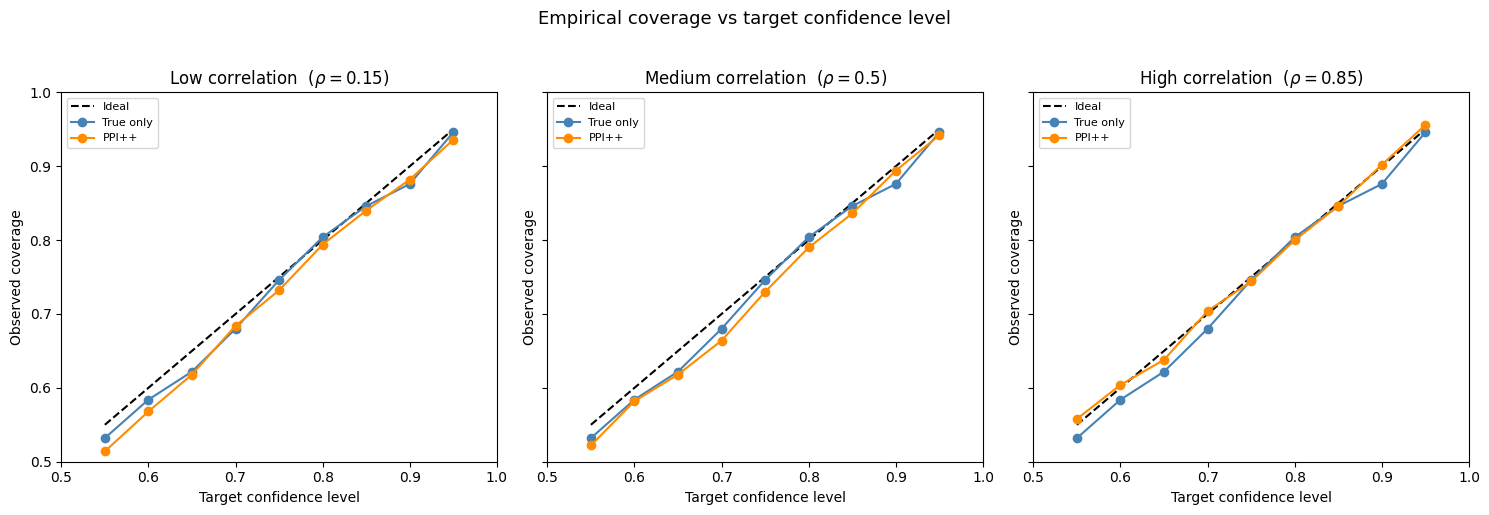

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
plot_methods = ['True only', 'PPI++']
colors = {'True only': 'steelblue', 'PPI++': 'darkorange'}

for ax, rho, label in zip(axes, correlations_3, corr_labels):
    ax.plot(confidence_levels, confidence_levels, color='black', lw=1.5,
            linestyle='--', label='Ideal')
    for m in plot_methods:
        obs = [coverage_by_corr_cl[rho][cl][m] for cl in confidence_levels]
        ax.plot(confidence_levels, obs, marker='o', label=m, color=colors[m])
    ax.set_xlabel('Target confidence level')
    ax.set_ylabel('Observed coverage')
    ax.set_title(f'{label} correlation  ($\\rho = {rho}$)')
    ax.legend(fontsize=8)
    ax.set_xlim(0.5, 1.0)
    ax.set_ylim(0.5, 1.0)

fig.suptitle('Empirical coverage vs target confidence level', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Both **PPI++** and **True only** track the diagonal closely across all correlation levels, confirming that PPI++ achieves valid coverage regardless of proxy quality.

---

### Coverage vs correlation — for fixed confidence level = 0.9

We now fix the confidence level at 90% and vary the proxy-true correlation from 0.1 to 0.9.
This shows that PPI++' validity does not degrade as the proxy becomes weaker.

In [19]:
# Single simulation sweep for the full correlations grid.
# Results are stored in raw_stats and reused by sections 3, 4, and 5.
raw_stats = {rho: simulate_all(rho) for rho in correlations}

In [20]:
# Compute empirical coverage + error bars via ClassicalMeanEstimator on per-seed hit vectors.
coverage_by_corr    = {}   # {rho: {method: observed mean coverage}}
coverage_ci_by_corr = {}   # {rho: {method: (lower, upper) CI on coverage}}

for rho in correlations:
    hits = compute_hits(raw_stats[rho], CONFIDENCE_LEVEL)
    coverage_by_corr[rho]    = {}
    coverage_ci_by_corr[rho] = {}
    for m in METHODS:
        mean_cov, lo, hi = coverage_with_errbar(hits[m])
        coverage_by_corr[rho][m]    = mean_cov
        coverage_ci_by_corr[rho][m] = (lo, hi)

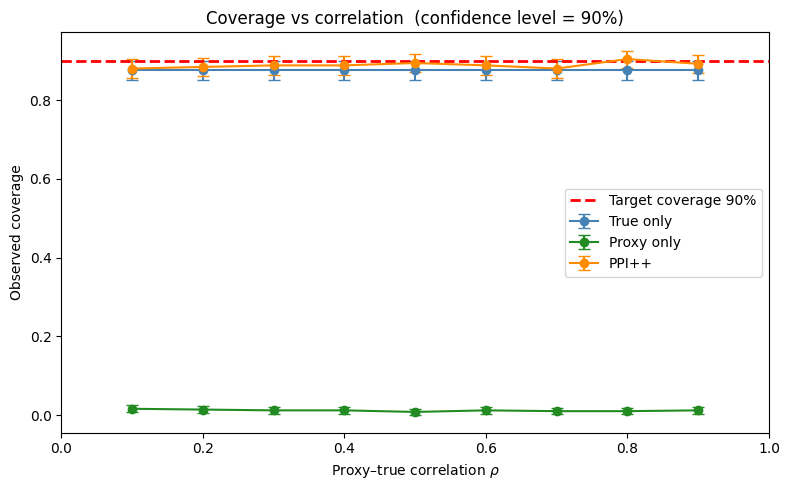

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
method_colors = {'True only': 'steelblue', 'Proxy only': 'forestgreen', 'PPI++': 'darkorange'}

for m in METHODS:
    obs  = [coverage_by_corr[rho][m] for rho in correlations]
    lo   = [coverage_ci_by_corr[rho][m][0] for rho in correlations]
    hi   = [coverage_ci_by_corr[rho][m][1] for rho in correlations]
    yerr = [
        [o - l for o, l in zip(obs, lo)],
        [h - o for h, o in zip(hi, obs)],
    ]
    ax.errorbar(correlations, obs, yerr=yerr, marker='o', label=m,
                color=method_colors[m], capsize=4)

ax.axhline(y=CONFIDENCE_LEVEL, color='red', linestyle='--', lw=2,
           label=f'Target coverage {CONFIDENCE_LEVEL:.0%}')
ax.set_xlabel('Proxy–true correlation $\\rho$')
ax.set_ylabel('Observed coverage')
ax.set_title(f'Coverage vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

Note that **Proxy only** under-covers because the proxy is biased (proxy mean ≠ true mean). Only **PPI++** and **True only** remain valid across all correlation levels.

---

## 4. Confidence Interval Width

Coverage validity is necessary but not sufficient — we also want **short** intervals. PPI++'s promise is that by leveraging the unlabeled proxy data, it achieves the same validity as using labeled data alone, but with a shorter interval when the proxy is informative.

We measure CI widths over `N_SEEDS` Monte Carlo runs and report the **mean** and the **10th–90th percentile band** to capture variability.

In [22]:
# Derive CI widths from the same per-seed stats — no additional simulation needed.
z_score = sp_norm.ppf((1 + CONFIDENCE_LEVEL) / 2)
width_by_corr = {
    rho: {m: 2 * z_score * raw_stats[rho][m]['stds'] for m in METHODS}
    for rho in correlations
}

### CI width (mean ± quantiles) vs correlation

The shaded bands show the 10th–90th percentile range across Monte Carlo runs.
At high correlation, PPI's CI should be substantially narrower than true-only.

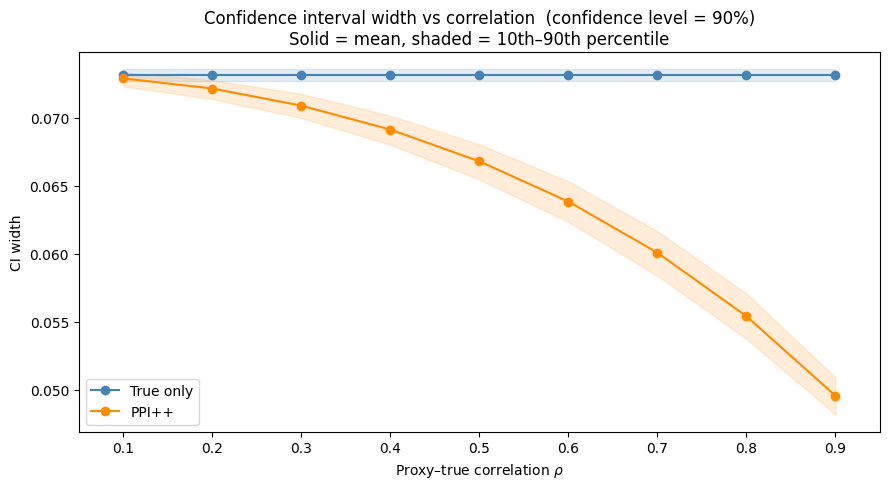

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_methods_w = ['True only', 'PPI++']
colors_w = {'True only': 'steelblue', 'PPI++': 'darkorange'}

for m in plot_methods_w:
    means_w = [np.mean(width_by_corr[rho][m]) for rho in correlations]
    q10 = [np.percentile(width_by_corr[rho][m], 10) for rho in correlations]
    q90 = [np.percentile(width_by_corr[rho][m], 90) for rho in correlations]
    ax.plot(correlations, means_w, marker='o', label=m, color=colors_w[m])
    ax.fill_between(correlations, q10, q90, alpha=0.15, color=colors_w[m])

ax.set_xlabel('Proxy–true correlation $\\rho$')
ax.set_ylabel('CI width')
ax.set_title(f'Confidence interval width vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})\n'
             'Solid = mean, shaded = 10th–90th percentile')
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

As expected, PPI++' interval width decreases with increasing correlation — leveraging the unlabeled proxy data is only beneficial when the proxy is informative. At low correlation, PPI++ still produces valid intervals, just without much efficiency gain over labeled-only.

---

## 5. Effective Sample Size

A natural summary of PPI's efficiency gain is the **Effective Sample Size (ESS)**: *how many additional labeled samples would be needed to achieve the same CI width as PPI++?*

Since CI width $\propto 1/\sqrt{n}$, we can estimate ESS empirically as:

$$\text{ESS}(\rho) = N_{\text{true}} \times \left(\frac{\bar{w}_{\text{True only}}}{\bar{w}_{\text{PPI++}}}\right)^2$$

When $\rho = 0,~$ ESS $\approx N_{\text{labeled}}$ (no gain)$.~$ As $\rho \to 1,~$ ESS grows — PPI++ can be equivalent to having a much larger labeled dataset.

In [24]:
# Compute ESS statistics from the cached raw_stats — no additional simulation needed.
ess_mean = [np.mean(raw_stats[rho]['PPI++']['ess']) for rho in correlations]
ess_q10  = [np.percentile(raw_stats[rho]['PPI++']['ess'], 10) for rho in correlations]
ess_q90  = [np.percentile(raw_stats[rho]['PPI++']['ess'], 90) for rho in correlations]

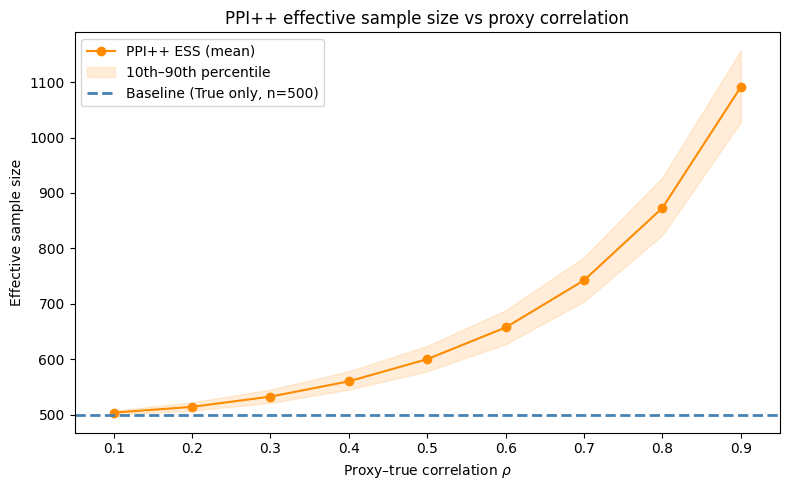

ESS summary:
  ρ = 0.1  →  ESS = 503  (×1.01 labeled)
  ρ = 0.2  →  ESS = 514  (×1.03 labeled)
  ρ = 0.3  →  ESS = 532  (×1.06 labeled)
  ρ = 0.4  →  ESS = 560  (×1.12 labeled)
  ρ = 0.5  →  ESS = 600  (×1.20 labeled)
  ρ = 0.6  →  ESS = 657  (×1.31 labeled)
  ρ = 0.7  →  ESS = 742  (×1.48 labeled)
  ρ = 0.8  →  ESS = 873  (×1.75 labeled)
  ρ = 0.9  →  ESS = 1091  (×2.18 labeled)


In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(correlations, ess_mean, marker='o', color='darkorange', label='PPI++ ESS (mean)')
ax.fill_between(correlations, ess_q10, ess_q90, alpha=0.15, color='darkorange',
                label='10th–90th percentile')
ax.axhline(y=N_TRUE, color='steelblue', linestyle='--', lw=2,
           label=f'Baseline (True only, n={N_TRUE})')
ax.set_xlabel('Proxy–true correlation $\\rho$')
ax.set_ylabel('Effective sample size')
ax.set_title('PPI++ effective sample size vs proxy correlation')
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

print("ESS summary:")
for rho, ess in zip(correlations, ess_mean):
    print(f"  ρ = {rho:.1f}  →  ESS = {ess:.0f}  (×{ess/N_TRUE:.2f} labeled)")

## Summary

This notebook has empirically validated that GLIDE's PPI++ implementation satisfies two key statistical properties:

| Property | Result |
|----------|--------|
| **Coverage validity** | PPI++ achieves the nominal coverage across all correlation levels and confidence levels tested |
| **Efficiency** | PPI++ produces shorter CIs than labeled-only whenever $\rho > 0$, with the gain growing with correlation |

Crucially, the biased baseline (**Proxy only**) fails the coverage test — it appears precise but is systematically wrong. PPI++ avoids this by correcting for proxy bias using the labeled subset.

The ESS analysis shows that with a proxy correlation of $\rho = 0.8,~$ PPI++ is equivalent to having roughly **twice more labeled data** — a significant practical gain in scenarios where true annotation is expensive.

You can download this notebook [here](https://github.com/EmertonData/glide/raw/refs/heads/main/docs/examples/PPI_demo_synthdata_binary.ipynb)